In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

BASE_DIR = r"E:\Research\Paper_A_XAI_IDS"
RAW_DIR = os.path.join(BASE_DIR, "02_Data", "raw", "NSL-KDD")
PROCESSED_DIR = os.path.join(BASE_DIR, "02_Data", "processed")
FIG_RAW_DIR = os.path.join(BASE_DIR, "05_Figures", "raw")
NOTES_DIR = os.path.join(BASE_DIR, "07_Notes")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIG_RAW_DIR, exist_ok=True)
os.makedirs(NOTES_DIR, exist_ok=True)

train_path = os.path.join(RAW_DIR, "KDDTrain+.txt")
test_path = os.path.join(RAW_DIR, "KDDTest+.txt")

print("Train exists:", os.path.exists(train_path), train_path)
print("Test exists :", os.path.exists(test_path), test_path)

Train exists: True E:\Research\Paper_A_XAI_IDS\02_Data\raw\NSL-KDD\KDDTrain+.txt
Test exists : True E:\Research\Paper_A_XAI_IDS\02_Data\raw\NSL-KDD\KDDTest+.txt


In [2]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv(train_path, header=None, names=col_names)
test_df = pd.read_csv(test_path, header=None, names=col_names)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()

Train shape: (125973, 43)
Test shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
print("Train info")
print(train_df.info())

print("\nTest info")
print(test_df.info())

Train info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  i

In [4]:
print("Train missing values:")
display(train_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTest missing values:")
display(test_df.isnull().sum().sort_values(ascending=False).head(10))

Train missing values:


duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64


Test missing values:


duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64

In [5]:
summary_df = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [train_df.shape[0], test_df.shape[0]],
    "columns": [train_df.shape[1], test_df.shape[1]],
    "duplicates": [train_df.duplicated().sum(), test_df.duplicated().sum()],
    "missing_values_total": [train_df.isnull().sum().sum(), test_df.isnull().sum().sum()]
})

summary_df

,dataset,rows,columns,duplicates,missing_values_total
0,train,125973,43,0,0
1,test,22544,43,0,0


In [6]:
summary_path = os.path.join(PROCESSED_DIR, "week1_dataset_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)

Saved: E:\Research\Paper_A_XAI_IDS\02_Data\processed\week1_dataset_summary.csv


In [7]:
print("Unique attack labels in train:", train_df["label"].nunique())
print("Unique attack labels in test :", test_df["label"].nunique())

train_label_counts = train_df["label"].value_counts()
test_label_counts = test_df["label"].value_counts()

display(train_label_counts.head(15))
display(test_label_counts.head(15))

Unique attack labels in train: 23
Unique attack labels in test : 38


label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
Name: count, dtype: int64

label
normal           9711
neptune          4657
guess_passwd     1231
mscan             996
warezmaster       944
apache2           737
satan             735
processtable      685
smurf             665
back              359
snmpguess         331
saint             319
mailbomb          293
snmpgetattack     178
portsweep         157
Name: count, dtype: int64

In [8]:
def to_binary(label):
    return "normal" if label == "normal" else "attack"

train_df["binary_label"] = train_df["label"].apply(to_binary)
test_df["binary_label"] = test_df["label"].apply(to_binary)

print(train_df["binary_label"].value_counts())
print(test_df["binary_label"].value_counts())

binary_label
normal    67343
attack    58630
Name: count, dtype: int64
binary_label
attack    12833
normal     9711
Name: count, dtype: int64


In [9]:
attack_category_map = {
    "normal": "normal",

    "back": "dos", "land": "dos", "neptune": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "mailbomb": "dos", "apache2": "dos", "processtable": "dos",
    "udpstorm": "dos", "worm": "dos",

    "ipsweep": "probe", "nmap": "probe", "portsweep": "probe", "satan": "probe",
    "mscan": "probe", "saint": "probe",

    "ftp_write": "r2l", "guess_passwd": "r2l", "imap": "r2l", "multihop": "r2l",
    "phf": "r2l", "spy": "r2l", "warezclient": "r2l", "warezmaster": "r2l",
    "sendmail": "r2l", "named": "r2l", "snmpgetattack": "r2l", "snmpguess": "r2l",
    "xlock": "r2l", "xsnoop": "r2l", "httptunnel": "r2l",

    "buffer_overflow": "u2r", "loadmodule": "u2r", "perl": "u2r", "rootkit": "u2r",
    "ps": "u2r", "sqlattack": "u2r", "xterm": "u2r"
}

train_df["attack_category"] = train_df["label"].map(attack_category_map)
test_df["attack_category"] = test_df["label"].map(attack_category_map)

print(train_df["attack_category"].value_counts(dropna=False))
print(test_df["attack_category"].value_counts(dropna=False))

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64
attack_category
normal    9711
dos       7460
r2l       2885
probe     2421
u2r         67
Name: count, dtype: int64


In [10]:
unknown_train = train_df[train_df["attack_category"].isna()]["label"].unique().tolist()
unknown_test = test_df[test_df["attack_category"].isna()]["label"].unique().tolist()

print("Unknown labels in train:", unknown_train)
print("Unknown labels in test :", unknown_test)

Unknown labels in train: []
Unknown labels in test : []


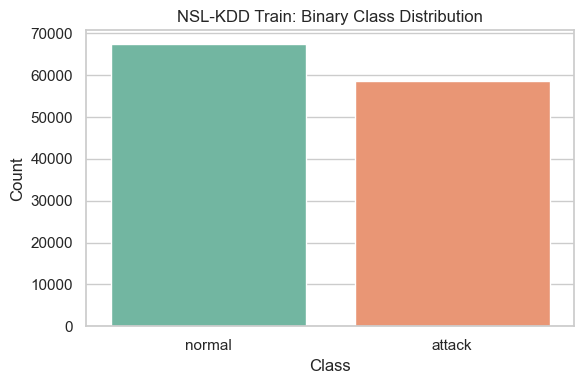

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\week1_binary_class_distribution_train.png


In [11]:
binary_counts = train_df["binary_label"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="binary_label", order=binary_counts.index, palette="Set2")
plt.title("NSL-KDD Train: Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

fig1_path = os.path.join(FIG_RAW_DIR, "week1_binary_class_distribution_train.png")
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig1_path)

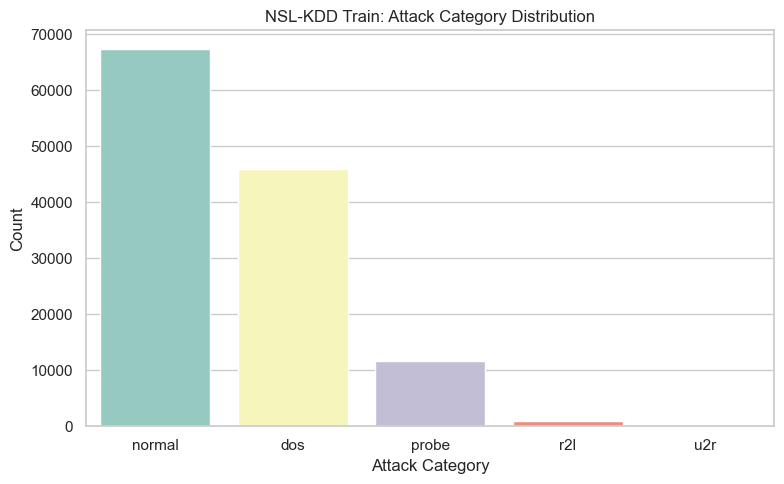

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\week1_attack_category_distribution_train.png


In [12]:
category_order = train_df["attack_category"].value_counts().index

plt.figure(figsize=(8,5))
sns.countplot(data=train_df, x="attack_category", order=category_order, palette="Set3")
plt.title("NSL-KDD Train: Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.tight_layout()

fig2_path = os.path.join(FIG_RAW_DIR, "week1_attack_category_distribution_train.png")
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)

In [13]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
basic_stats = train_df[numeric_cols].describe().T

basic_stats_path = os.path.join(PROCESSED_DIR, "week1_numeric_summary_train.csv")
basic_stats.to_csv(basic_stats_path)

basic_stats.head(10)

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


In [14]:
print("Saved:", basic_stats_path)

Saved: E:\Research\Paper_A_XAI_IDS\02_Data\processed\week1_numeric_summary_train.csv


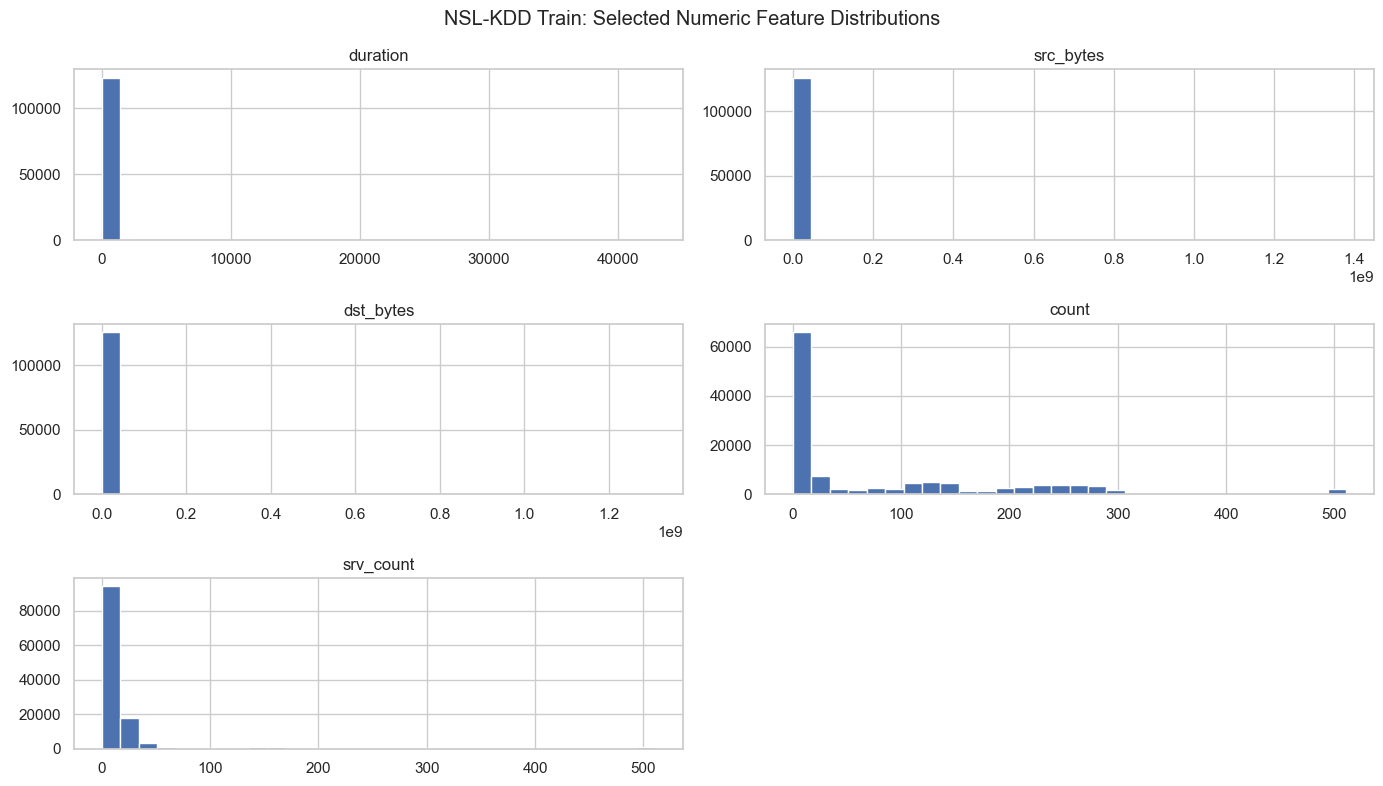

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\week1_selected_feature_histograms.png


In [15]:
selected_features = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]

train_df[selected_features].hist(bins=30, figsize=(14,8))
plt.suptitle("NSL-KDD Train: Selected Numeric Feature Distributions")
plt.tight_layout()

fig3_path = os.path.join(FIG_RAW_DIR, "week1_selected_feature_histograms.png")
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig3_path)

In [16]:
categorical_cols = ["protocol_type", "service", "flag"]

for col in categorical_cols:
    print(f"\nTop categories in {col}:")
    display(train_df[col].value_counts().head(10))


Top categories in protocol_type:


protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


Top categories in service:


service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64


Top categories in flag:


flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64

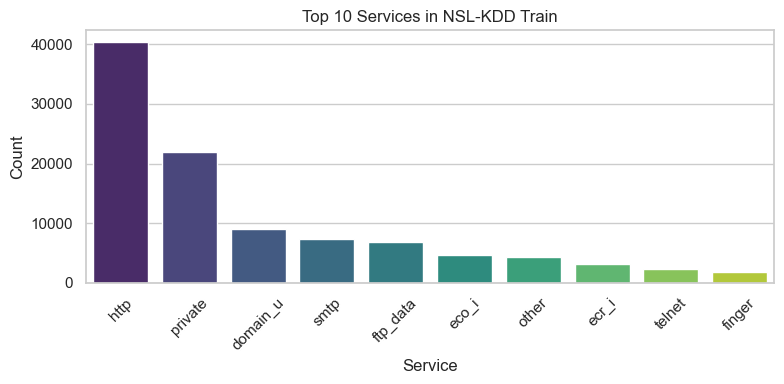

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\week1_top10_services_train.png


In [17]:
plt.figure(figsize=(8,4))
top_services = train_df["service"].value_counts().head(10)

sns.barplot(x=top_services.index, y=top_services.values, palette="viridis")
plt.title("Top 10 Services in NSL-KDD Train")
plt.xlabel("Service")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

fig4_path = os.path.join(FIG_RAW_DIR, "week1_top10_services_train.png")
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig4_path)

In [18]:
eda_notes = []
eda_notes.append("Week 1 NSL-KDD EDA Summary")
eda_notes.append("=" * 40)
eda_notes.append(f"Train shape: {train_df.shape}")
eda_notes.append(f"Test shape: {test_df.shape}")
eda_notes.append(f"Train duplicates: {train_df.duplicated().sum()}")
eda_notes.append(f"Test duplicates: {test_df.duplicated().sum()}")
eda_notes.append(f"Train missing values: {train_df.isnull().sum().sum()}")
eda_notes.append(f"Test missing values: {test_df.isnull().sum().sum()}")
eda_notes.append("\nTrain binary class distribution:")
eda_notes.append(str(train_df['binary_label'].value_counts()))
eda_notes.append("\nTrain attack category distribution:")
eda_notes.append(str(train_df['attack_category'].value_counts()))

notes_path = os.path.join(NOTES_DIR, "week1_eda_notes.txt")
with open(notes_path, "w", encoding="utf-8") as f:
    f.write("\n".join(eda_notes))

print("Saved:", notes_path)

Saved: E:\Research\Paper_A_XAI_IDS\07_Notes\week1_eda_notes.txt


In [19]:
print("All Week 1 outputs created successfully.")
print("Check these folders:")
print(os.path.join(BASE_DIR, "02_Data", "processed"))
print(os.path.join(BASE_DIR, "05_Figures", "raw"))
print(os.path.join(BASE_DIR, "07_Notes"))

All Week 1 outputs created successfully.
Check these folders:
E:\Research\Paper_A_XAI_IDS\02_Data\processed
E:\Research\Paper_A_XAI_IDS\05_Figures\raw
E:\Research\Paper_A_XAI_IDS\07_Notes
